In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [ ]:
import os
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from matplotlib.gridspec import GridSpec

# Defining Global Variable

In [3]:
x_star = 1/3 * (-2 + np.cbrt(19-3*np.sqrt(33)) + np.cbrt(19+3*np.sqrt(33)))
theta = np.arcsin(x_star)

# Graphing Settings

In [21]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# 2-Qubit MSD Circuit

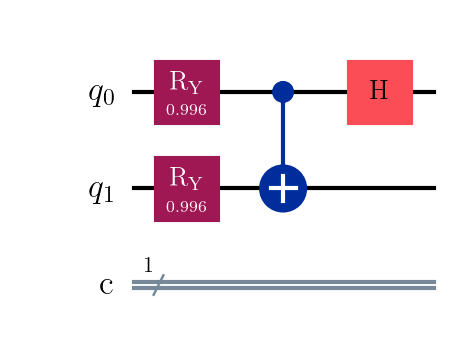

In [5]:
qc = QuantumCircuit(2,1)

# State preparation
qc.ry(theta,0)
qc.ry(theta,1)

# Distillation circuit
qc.cx(0,1)
qc.h(0)

display(qc.draw(output='mpl'))

# Infidelity to Error Rates

In [6]:
def inf_to_error(infidelity_list, num_qubits, infidelity_uncertainty_list=None):
    if infidelity_uncertainty_list is None:
        error_rates_list = []
        dimension = 2**num_qubits
        for infidelity in infidelity_list:
            error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
        
        return error_rates_list
    else:
        error_rates_list = []
        error_uncertainty_list = []

        dimension = 2**num_qubits
        scale = dimension / (dimension - 1)

        for infidelity, uncertainty in zip(infidelity_list, infidelity_uncertainty_list):
            error_rates_list.append(scale * infidelity)
            error_uncertainty_list.append(scale * uncertainty)

        return error_rates_list, error_uncertainty_list

In [7]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [8]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Threshold Simulations

In [9]:
input_error_rate_list = np.linspace(0.5,0.9, 500)

Consider the case when only state preparation is noisy

In [10]:
ideal = QuantumCircuit(2)
ideal.ry(theta,0)
ideal_dm = DensityMatrix(ideal)

In [11]:
fid_list_noisy_prep = []
shots = 50

for i in range(len(input_error_rate_list)):
    noise_model = NoiseModel()
    # Add depolarizing noise to state preparation gate. 
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(input_error_rate_list[i], 1),
        ['ry']
    )
    
    # Measure for post-selection and save the conditional density matrix.
    meas_circuit = qc.copy()
    meas_circuit.measure([1], [0])
    meas_circuit.append(
        SaveDensityMatrix(
            num_qubits=2,
            label='dm_post',
            conditional=True,
            pershot=True
        ),
        meas_circuit.qubits
    )
    
    # Run the noisy simulation.
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit, shots=shots)
    result = job.result()

    # Keep a post-selected run with measurement outcome 0, and compute its fidelity.
    res_dm = result.data()['dm_post']
    temp_fid = state_fidelity(ideal_dm, res_dm['0x0'][0])
    fid_list_noisy_prep.append(temp_fid)

infid_list_noisy_prep = [1-f for f in fid_list_noisy_prep]

In [12]:
# Finding the intersection of the curve with y=x
output_error_rate = inf_to_error(infid_list_noisy_prep, 1)
y = output_error_rate
x = input_error_rate_list

diff = y - x

# Find where the sign changes
idx = np.where(diff[:-1] * diff[1:] <= 0)[0][0]

# Interpolate intersection in log-log space
logx1, logx2 = np.log(x[idx]), np.log(x[idx + 1])
logy1, logy2 = np.log(y[idx]), np.log(y[idx + 1])

# Interpolate log(output/input)
f1 = logy1 - logx1
f2 = logy2 - logx2

logx_intersect = logx1 - f1 * (logx2 - logx1) / (f2 - f1)
x_intersect = np.exp(logx_intersect)
y_intersect = x_intersect

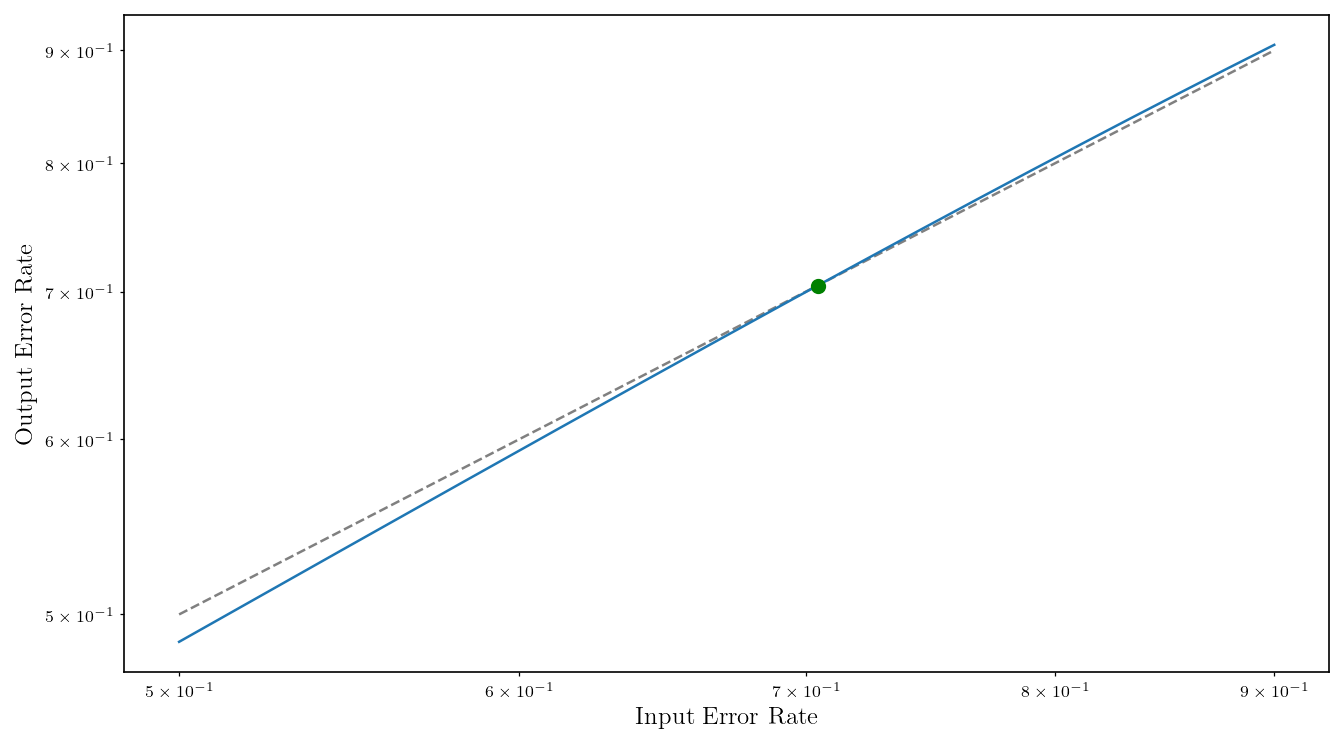

In [13]:
plt.figure(figsize=(9, 5))

plt.plot(input_error_rate_list, input_error_rate_list, color="gray", linestyle="--")
plt.plot(input_error_rate_list, output_error_rate)
plt.scatter(x_intersect, y_intersect, color="green", s=40, zorder=5,)
plt.xlabel("Input Error Rate", fontsize=12)
plt.ylabel("Output Error Rate", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.show()

In [14]:
print(x_intersect)

0.7044023647315808


# Error Contribution Simulations

Ideal output

In [15]:
ideal = QuantumCircuit(2)
ideal.ry(theta,0)
ideal_dm = DensityMatrix(ideal)

In [16]:
ideal_infidelity_list = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    # Add depolarizing noise to state preparation gate. 
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['ry']
    )
    
    # Measure for post-selection and save the conditional density matrix.
    meas_circuit = qc.copy()
    meas_circuit.measure([1], [0])
    meas_circuit.append(
        SaveDensityMatrix(
            num_qubits=2,
            label='dm_post',
            conditional=True,
            pershot=True
        ),
        meas_circuit.qubits
    )
    
    # Run the noisy simulation.
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit, shots=shots)
    result = job.result()

    # Keep a post-selected run with measurement outcome 0, and compute its fidelity.
    res_dm = result.data()['dm_post']
    temp_fid = state_fidelity(ideal_dm, res_dm['0x0'][0])
    ideal_infidelity_list.append(1-temp_fid)

ideal_output_error_rate = inf_to_error(ideal_infidelity_list, 1)

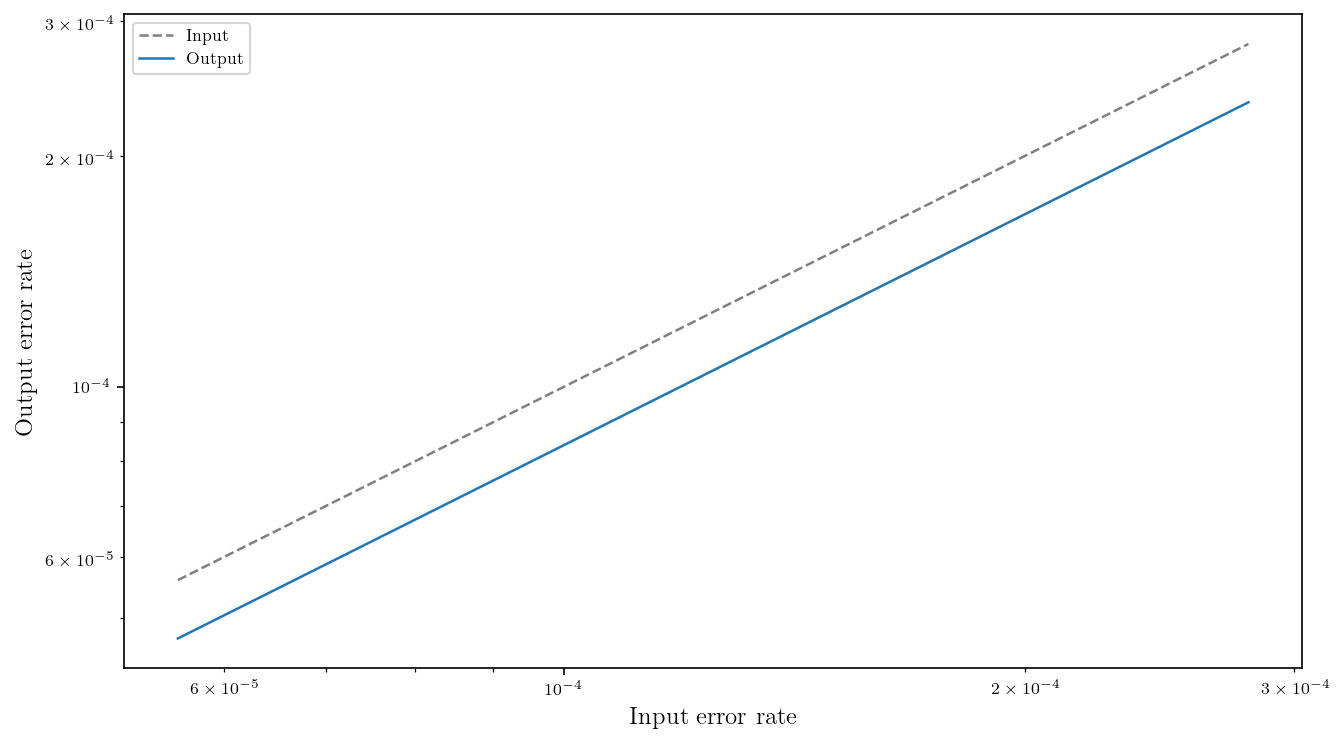

In [23]:
plt.figure(figsize=(9, 5))

plt.plot(one_qubit_gate_error_prob, one_qubit_gate_error_prob, color="gray", linestyle="--", label="Input")
plt.plot(one_qubit_gate_error_prob, ideal_output_error_rate, label="Output")
plt.xlabel("Input error rate", fontsize=12)
plt.ylabel("Output error rate", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.legend()
plt.show()

Only cx errors

In [18]:
cx_infidelity_list = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    # Add depolarizing noise to state preparation gate. 
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['ry']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(two_qubit_gate_error_prob[i], 2),
        ['cx']
    )
    
    # Measure for post-selection and save the conditional density matrix.
    meas_circuit = qc.copy()
    meas_circuit.measure([1], [0])
    meas_circuit.append(
        SaveDensityMatrix(
            num_qubits=2,
            label='dm_post',
            conditional=True,
            pershot=True
        ),
        meas_circuit.qubits
    )
    
    # Run the noisy simulation.
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit, shots=shots)
    result = job.result()

    # Keep a post-selected run with measurement outcome 0, and compute its fidelity.
    res_dm = result.data()['dm_post']
    temp_fid = state_fidelity(ideal_dm, res_dm['0x0'][0])
    cx_infidelity_list.append(1-temp_fid)

cx_output_error_rate = inf_to_error(cx_infidelity_list, 1)

Only H errors

In [19]:
h_infidelity_list = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    # Add depolarizing noise to state preparation gate. 
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['ry']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['h']
    )
    
    # Measure for post-selection and save the conditional density matrix.
    meas_circuit = qc.copy()
    meas_circuit.measure([1], [0])
    meas_circuit.append(
        SaveDensityMatrix(
            num_qubits=2,
            label='dm_post',
            conditional=True,
            pershot=True
        ),
        meas_circuit.qubits
    )
    
    # Run the noisy simulation.
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit, shots=shots)
    result = job.result()

    # Keep a post-selected run with measurement outcome 0, and compute its fidelity.
    res_dm = result.data()['dm_post']
    temp_fid = state_fidelity(ideal_dm, res_dm['0x0'][0])
    h_infidelity_list.append(1-temp_fid)

h_output_error_rate = inf_to_error(h_infidelity_list, 1)

Only measurement errors

In [20]:
meas_infidelity_list = []
meas_infidelity_list_unc = []
shots = 1_000_000
ncpus = os.cpu_count()

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    # Add depolarizing noise to state preparation gate. 
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['ry']
    )
    
    # Add readout errors on the measured qubits.
    readout_err = ReadoutError([
        [1 - spam0[i], spam0[i]],
        [spam1[i], 1 - spam1[i]]
    ])
    noise_model.add_readout_error(readout_err, [1])
    
    # Measure for post-selection and save the conditional density matrix.
    meas_circuit = qc.copy()
    meas_circuit.measure([1], [0])
    meas_circuit.append(
        SaveStatevector(
            num_qubits=2,
            label='sv_post',
            conditional=True,
            pershot=True
        ),
        meas_circuit.qubits
    )
    
    # Run the noisy simulation.
    backend = AerSimulator(noise_model=noise_model, method='statevector', max_parallel_threads=ncpus)
    job = backend.run(meas_circuit, shots=shots)
    result = job.result()

    # Keep a post-selected run with measurement outcome 0, and compute its fidelity.
    res_sv = result.data()['sv_post']
    accepted_sv = res_sv['0x0']
    num_meas = len(accepted_sv)
    
    # Average fidelity over accepted shots
    sumfid = 0
    for shot in accepted_sv:
        sumfid += state_fidelity(ideal_dm, shot)
        
    sumfid /= num_meas
    meas_infidelity_list.append(1-sumfid)
    
    meas_infidelity_list_unc.append(
        1.96 * np.sqrt(sumfid * (1 - sumfid) / num_meas)
    )
    
meas_output_error_rate, meas_output_error_rate_unc = inf_to_error(meas_infidelity_list, 1, meas_infidelity_list_unc)

All errors

In [22]:
all_infidelity_list = []
all_infidelity_list_unc = []
shots = 1_000_000
ncpus = os.cpu_count()

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    # Add depolarizing noise to state preparation gate. 
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['ry']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['h']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(two_qubit_gate_error_prob[i], 2),
        ['cx']
    )
    
    # Add readout errors on the measured qubits.
    readout_err = ReadoutError([
        [1 - spam0[i], spam0[i]],
        [spam1[i], 1 - spam1[i]]
    ])
    noise_model.add_readout_error(readout_err, [1])
    
    # Measure for post-selection and save the conditional density matrix.
    meas_circuit = qc.copy()
    meas_circuit.measure([1], [0])
    meas_circuit.append(
        SaveStatevector(
            num_qubits=2,
            label='sv_post',
            conditional=True,
            pershot=True
        ),
        meas_circuit.qubits
    )
    
    # Run the noisy simulation.
    backend = AerSimulator(noise_model=noise_model, method='statevector', max_parallel_threads=ncpus)
    job = backend.run(meas_circuit, shots=shots)
    result = job.result()

    # Keep a post-selected run with measurement outcome 0, and compute its fidelity.
    res_sv = result.data()['sv_post']
    accepted_sv = res_sv['0x0']
    num_meas = len(accepted_sv)
    
    # Average fidelity over accepted shots
    sumfid = 0
    for shot in accepted_sv:
        sumfid += state_fidelity(ideal_dm, shot)
        
    sumfid /= num_meas
    all_infidelity_list.append(1-sumfid)
    
    all_infidelity_list_unc.append(
        1.96 * np.sqrt(sumfid * (1 - sumfid) / num_meas)
    )
    
all_output_error_rate, all_output_error_rate_unc = inf_to_error(all_infidelity_list, 1, all_infidelity_list_unc)

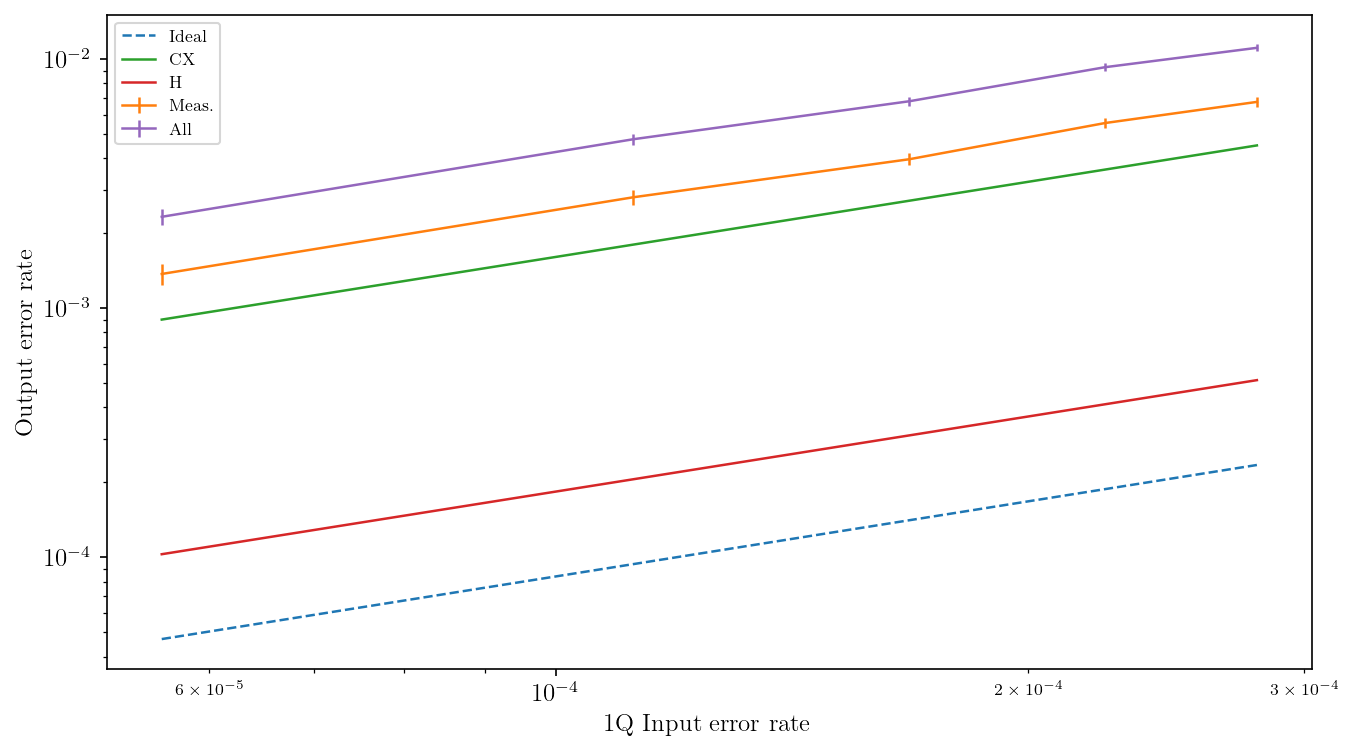

In [24]:
# Every plot without input and ideal circuit
plt.figure(figsize=(9,5))

plt.plot(one_qubit_gate_error_prob, ideal_output_error_rate, linestyle=f'--', label='Ideal')
plt.errorbar(one_qubit_gate_error_prob, meas_output_error_rate, yerr=meas_output_error_rate_unc, label='Meas.')
plt.plot(one_qubit_gate_error_prob, cx_output_error_rate, label='CX')
plt.plot(one_qubit_gate_error_prob, h_output_error_rate, label='H')
plt.errorbar(one_qubit_gate_error_prob, all_output_error_rate, yerr=all_output_error_rate_unc, label='All')

plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.ylabel('Output error rate', fontsize=12)
plt.xlabel('1Q Input error rate', fontsize=12)
plt.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Calculating error contributions

In [25]:
sum_c_list = []
for i in range(len(one_qubit_gate_error_prob)):
    sum_c_list.append(h_output_error_rate[i] + cx_output_error_rate[i] + meas_output_error_rate[i])

hadamard_contributions = 0
cx_contributions = 0
measurement_contributions = 0
for i in range(len(one_qubit_gate_error_prob)):
    hadamard_contributions += h_output_error_rate[i] / sum_c_list[i]
    cx_contributions += cx_output_error_rate[i] / sum_c_list[i]
    measurement_contributions += meas_output_error_rate[i] / sum_c_list[i]

hadamard_contributions /= len(one_qubit_gate_error_prob)
cx_contributions /= len(one_qubit_gate_error_prob)
measurement_contributions /= len(one_qubit_gate_error_prob)

# Saving Data

In [62]:
np.savez(
    "depolarizing_error_rates.npz",
    input_error_rate_list=input_error_rate_list,
    output_error_rate=output_error_rate,
    intersection=x_intersect,
    ideal_output_error_rate=ideal_output_error_rate,
    cx_output_error_rate=cx_output_error_rate,
    h_output_error_rate=h_output_error_rate,
    meas_output_error_rate=meas_output_error_rate,
    meas_output_error_rate_unc=meas_output_error_rate_unc,
    all_output_error_rate=all_output_error_rate,
    all_output_error_rate_unc=all_output_error_rate_unc,
    hadamard_contributions=hadamard_contributions,
    cx_contributions=cx_contributions,
    measurement_contributions=measurement_contributions,
    one_qubit_gate_error_prob=one_qubit_gate_error_prob
)

# Loading Data

In [67]:
data = np.load("depolarizing_error_rates.npz")

input_error_rate_list = data["input_error_rate_list"]
output_error_rate = data["output_error_rate"]
intersection = data["intersection"]
ideal_output_error_rate = data["ideal_output_error_rate"]
cx_output_error_rate = data["cx_output_error_rate"]
h_output_error_rate = data["h_output_error_rate"]
meas_output_error_rate = data["meas_output_error_rate"]
meas_output_error_rate_unc = data["meas_output_error_rate_unc"]
all_output_error_rate = data["all_output_error_rate"]
all_output_error_rate_unc = data["all_output_error_rate_unc"]
hadamard_contributions = data["hadamard_contributions"]
cx_contributions = data["cx_contributions"]
measurement_contributions = data["measurement_contributions"]
one_qubit_gate_error_prob = data["one_qubit_gate_error_prob"]